# Notebook 3: Provisional COVID-19 Death Counts (CDC)
**Fuente:** https://data.cdc.gov/National-Center-for-Health-Statistics/Provisional-COVID-19-Death-Counts-by-Week-Ending-D/r8kw-7aab/about_data

Dataset de conteo provisional de muertes por COVID-19 por semana, estado y otras desagregaciones, publicado por los CDC (EE.UU.).

## Introducción
Este dataset contiene registros semanales de muertes provisionales por COVID-19 desglosadas por estado y otras variables demográficas. Se plantea como un problema de **regresión** para predecir el total de muertes por COVID-19 en una semana dado el estado, año, semana epidemiológica y otras variables disponibles. También permite análisis de series de tiempo.

## Carga del Dataset
El dataset puede descargarse directamente desde la API de datos.cdc.gov o cargarse como CSV desde Google Drive.

In [1]:
import os
import pandas as pd
import numpy as np

try:
    from google.colab import drive
    drive.mount('/content/drive')
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    EXPORT_PATH = '/content/drive/MyDrive/datasets/cdc_covid/'
else:
    EXPORT_PATH = './cdc_covid_output/'

os.makedirs(EXPORT_PATH, exist_ok=True)

# Descarga directa vía API Socrata (no requiere autenticación para datos públicos)
API_URL = 'https://data.cdc.gov/resource/r8kw-7aab.csv?$limit=50000'
print('Descargando dataset desde CDC API...')
df = pd.read_csv(API_URL)
print(f'Dataset cargado: {df.shape[0]} filas x {df.shape[1]} columnas')
df.head()

Mounted at /content/drive
Descargando dataset desde CDC API...
Dataset cargado: 22086 filas x 17 columnas


,data_as_of,start_date,end_date,group,year,month,mmwr_week,week_ending_date,state,covid_19_deaths,total_deaths,percent_of_expected_deaths,pneumonia_deaths,pneumonia_and_covid_19_deaths,influenza_deaths,pneumonia_influenza_or_covid_19_deaths,footnote
0,2026-04-02T00:00:00.000,2019-12-29T00:00:00.000,2020-01-04T00:00:00.000,By Week,2019/2020,NaN,1.0,2020-01-04T00:00:00.000,United States,0.0,60170.0,98.0,4111.0,0.0,434.0,4545.0,NaN
1,2026-04-02T00:00:00.000,2020-01-05T00:00:00.000,2020-01-11T00:00:00.000,By Week,2020,NaN,2.0,2020-01-11T00:00:00.000,United States,1.0,60734.0,97.0,4153.0,1.0,475.0,4628.0,NaN
2,2026-04-02T00:00:00.000,2020-01-12T00:00:00.000,2020-01-18T00:00:00.000,By Week,2020,NaN,3.0,2020-01-18T00:00:00.000,United States,2.0,59362.0,98.0,4066.0,2.0,468.0,4534.0,NaN
3,2026-04-02T00:00:00.000,2020-01-19T00:00:00.000,2020-01-25T00:00:00.000,By Week,2020,NaN,4.0,2020-01-25T00:00:00.000,United States,3.0,59162.0,99.0,3915.0,0.0,500.0,4418.0,NaN
4,2026-04-02T00:00:00.000,2020-01-26T00:00:00.000,2020-02-01T00:00:00.000,By Week,2020,NaN,5.0,2020-02-01T00:00:00.000,United States,0.0,58834.0,99.0,3818.0,0.0,481.0,4299.0,NaN


## Identificación del Tipo de Problema

In [2]:
print('Columnas disponibles:')
print(df.columns.tolist())

# Detectar columna objetivo
posibles = [c for c in df.columns if 'covid' in c.lower() and 'death' in c.lower()]
TARGET = posibles[0] if posibles else 'covid_19_deaths'
print(f'\nVariable objetivo: {TARGET}')
print(f'Dtype: {df[TARGET].dtype}')
print('\n→ Tipo de problema: REGRESIÓN (predicción de conteo de muertes semanales)')

Columnas disponibles:
['data_as_of', 'start_date', 'end_date', 'group', 'year', 'month', 'mmwr_week', 'week_ending_date', 'state', 'covid_19_deaths', 'total_deaths', 'percent_of_expected_deaths', 'pneumonia_deaths', 'pneumonia_and_covid_19_deaths', 'influenza_deaths', 'pneumonia_influenza_or_covid_19_deaths', 'footnote']

Variable objetivo: covid_19_deaths
Dtype: float64

→ Tipo de problema: REGRESIÓN (predicción de conteo de muertes semanales)


##  Análisis Exploratorio (EDA)

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

df.info()
display(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22086 entries, 0 to 22085
Data columns (total 17 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   data_as_of                              22086 non-null  object 
 1   start_date                              22086 non-null  object 
 2   end_date                                22086 non-null  object 
 3   group                                   22086 non-null  object 
 4   year                                    22032 non-null  object 
 5   month                                   4050 non-null   float64
 6   mmwr_week                               17604 non-null  float64
 7   week_ending_date                        17604 non-null  object 
 8   state                                   22086 non-null  object 
 9   covid_19_deaths                         16309 non-null  float64
 10  total_deaths                            22085 non-null  fl

,month,mmwr_week,covid_19_deaths,total_deaths,percent_of_expected_deaths,pneumonia_deaths,pneumonia_and_covid_19_deaths,influenza_deaths,pneumonia_influenza_or_covid_19_deaths
count,4050.000000,17604.000000,1.630900e+04,2.208500e+04,22032.000000,2.049900e+04,13589.000000,12998.000000,2.102300e+04
mean,6.320000,25.926380,6.107116e+02,7.334194e+03,113.139842,6.412253e+02,356.566340,35.800508,8.899809e+02
std,3.499613,15.320961,1.143862e+04,1.493841e+05,17.145671,1.271076e+04,6207.407099,607.658977,1.799738e+04
min,1.000000,1.000000,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000,0.000000e+00
25%,3.000000,12.000000,1.800000e+01,4.880000e+02,105.000000,4.000000e+01,11.000000,0.000000,4.700000e+01
50%,6.000000,26.000000,4.600000e+01,1.078000e+03,111.000000,7.900000e+01,26.000000,0.000000,1.000000e+02
75%,9.000000,39.000000,1.490000e+02,2.236000e+03,119.000000,1.920000e+02,89.000000,11.000000,2.640000e+02
max,12.000000,53.000000,1.244461e+06,2.013630e+07,737.000000,1.629374e+06,607211.000000,60956.000000,2.323092e+06


In [4]:
print('Valores nulos por columna:')
nulls = df.isnull().sum()
print(nulls[nulls > 0].sort_values(ascending=False))

Valores nulos por columna:
month                                     18036
influenza_deaths                           9088
pneumonia_and_covid_19_deaths              8497
footnote                                   6940
covid_19_deaths                            5777
mmwr_week                                  4482
week_ending_date                           4482
pneumonia_deaths                           1587
pneumonia_influenza_or_covid_19_deaths     1063
year                                         54
percent_of_expected_deaths                   54
total_deaths                                  1
dtype: int64


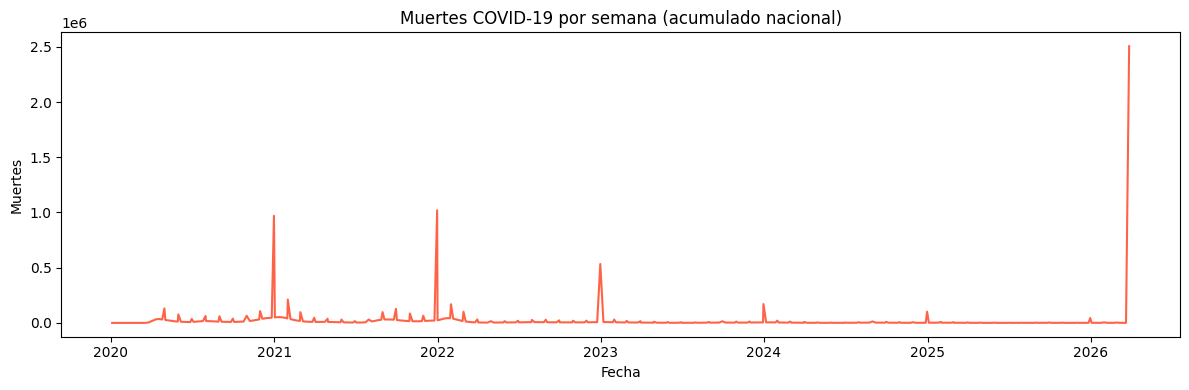

In [5]:
# Convertir target a numérico
df[TARGET] = pd.to_numeric(df[TARGET], errors='coerce')

# Evolución temporal si existe columna de fecha
date_col = next((c for c in df.columns if 'end_date' in c.lower() or 'week_ending' in c.lower()), None)
if date_col:
    df[date_col] = pd.to_datetime(df[date_col], errors='coerce')
    ts = df.groupby(date_col)[TARGET].sum().reset_index()
    plt.figure(figsize=(12,4))
    plt.plot(ts[date_col], ts[TARGET], color='tomato')
    plt.title('Muertes COVID-19 por semana (acumulado nacional)')
    plt.xlabel('Fecha')
    plt.ylabel('Muertes')
    plt.tight_layout()
    plt.show()
else:
    print('Columna de fecha no encontrada; revisar nombres de columnas.')

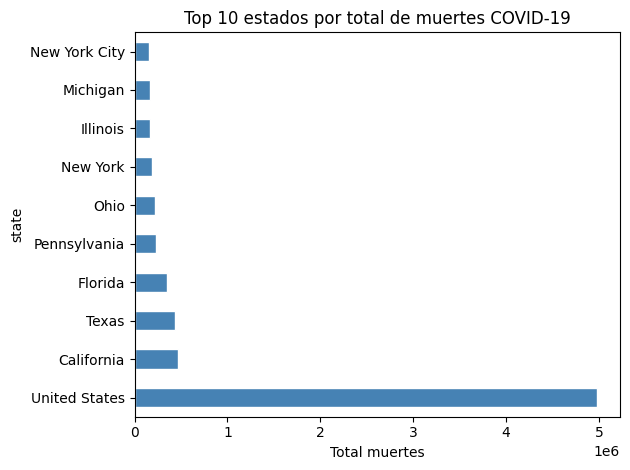

In [6]:
# Top estados por total de muertes
state_col = next((c for c in df.columns if 'state' in c.lower()), None)
if state_col:
    top_states = df.groupby(state_col)[TARGET].sum().sort_values(ascending=False).head(10)
    top_states.plot(kind='barh', color='steelblue', edgecolor='white')
    plt.title('Top 10 estados por total de muertes COVID-19')
    plt.xlabel('Total muertes')
    plt.tight_layout()
    plt.show()

## Limpieza y Preparació

In [7]:
df_clean = df.copy()

# Eliminar duplicados
print(f'Duplicados: {df_clean.duplicated().sum()}')
df_clean = df_clean.drop_duplicates()

# Eliminar filas sin target
df_clean = df_clean.dropna(subset=[TARGET])

# Convertir columnas numéricas
for col in df_clean.columns:
    if col != TARGET and df_clean[col].dtype == 'object':
        try:
            df_clean[col] = pd.to_numeric(df_clean[col], errors='ignore')
        except:
            pass

num_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df_clean.select_dtypes(include=['object']).columns.tolist()

# Imputar nulos numéricos con mediana
for col in num_cols:
    if df_clean[col].isnull().sum() > 0:
        df_clean[col].fillna(df_clean[col].median(), inplace=True)

# Imputar categóricos con 'UNKNOWN'
for col in cat_cols:
    df_clean[col].fillna('UNKNOWN', inplace=True)

print(f'Shape tras limpieza: {df_clean.shape}')
print(f'Nulos restantes: {df_clean.isnull().sum().sum()}')

Duplicados: 0
Shape tras limpieza: (16309, 17)
Nulos restantes: 0


/tmp/ipykernel_5081/665228385.py:14: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df_clean[col] = pd.to_numeric(df_clean[col], errors='ignore')
/tmp/ipykernel_5081/665228385.py:24: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_clean[col].fillna(df_clean[col].median(), inplace=True)
/tmp/ipykernel_5081/665228385.py:28: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chain

## Transformación y Preprocesamiento

In [8]:
from sklearn.preprocessing import LabelEncoder, StandardScaler

df_processed = df_clean.copy()

# Eliminar columnas de fecha (no útiles como features directos)
date_cols_to_drop = [c for c in df_processed.columns if df_processed[c].dtype == 'datetime64[ns]']

# Extraer features temporales si existe columna de fecha
if date_col and date_col in df_processed.columns:
    df_processed['year']  = df_processed[date_col].dt.year
    df_processed['month'] = df_processed[date_col].dt.month
    df_processed['week']  = df_processed[date_col].dt.isocalendar().week.astype(int)

df_processed = df_processed.drop(columns=date_cols_to_drop, errors='ignore')

# Re-detectar columnas
cat_cols_proc = df_processed.select_dtypes(include=['object']).columns.tolist()
num_cols_proc = [c for c in df_processed.select_dtypes(include=[np.number]).columns if c != TARGET]

le = LabelEncoder()
for col in cat_cols_proc:
    df_processed[col] = le.fit_transform(df_processed[col].astype(str))

scaler = StandardScaler()
df_processed[num_cols_proc] = scaler.fit_transform(df_processed[num_cols_proc])

print(f'Preprocesamiento completado. Shape: {df_processed.shape}')
df_processed.head()

Preprocesamiento completado. Shape: (16309, 17)


,data_as_of,start_date,group,year,month,mmwr_week,week_ending_date,state,covid_19_deaths,total_deaths,percent_of_expected_deaths,pneumonia_deaths,pneumonia_and_covid_19_deaths,influenza_deaths,pneumonia_influenza_or_covid_19_deaths,footnote,week
0,0,0,2,-1.314039,-1.484577,-1.815588,0,46,0.0,0.290464,-0.907214,0.232695,-0.053817,0.748157,0.166907,1,-1.571173
1,0,2,2,-1.314039,-1.484577,-1.742516,1,46,1.0,0.293710,-0.961730,0.235644,-0.053641,0.823711,0.170970,1,-1.508425
2,0,3,2,-1.314039,-1.484577,-1.669444,2,46,2.0,0.285815,-0.907214,0.229536,-0.053464,0.810812,0.166369,1,-1.445676
3,0,4,2,-1.314039,-1.484577,-1.596373,3,46,3.0,0.284664,-0.852698,0.218937,-0.053817,0.869781,0.160690,1,-1.382928
4,0,5,2,-1.314039,-1.209697,-1.523301,4,46,0.0,0.282776,-0.852698,0.212128,-0.053817,0.834768,0.154864,1,-1.320179


##  División Train/Test (80/20)

In [9]:
from sklearn.model_selection import train_test_split

X = df_processed.drop(columns=[TARGET])
y = df_processed[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, shuffle=True
)

train_df = X_train.copy(); train_df[TARGET] = y_train.values
test_df  = X_test.copy();  test_df[TARGET]  = y_test.values

print(f'Train: {train_df.shape}  |  Test: {test_df.shape}')

Train: (13047, 17)  |  Test: (3262, 17)


##  Exportación de train.csv y test.csv

In [10]:
train_df.to_csv(os.path.join(EXPORT_PATH, 'train.csv'), index=False)
test_df.to_csv(os.path.join(EXPORT_PATH, 'test.csv'), index=False)
print(f'✅ train.csv guardado: {train_df.shape}')
print(f'✅ test.csv  guardado: {test_df.shape}')

✅ train.csv guardado: (13047, 17)
✅ test.csv  guardado: (3262, 17)
